In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform

from Triangle.Constants import * 
from Triangle.GW import * 
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.TDI import *
from Triangle.Cosmology import *

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


no cupy 


/Users/taijidatacenter/miniconda3/envs/few_env/lib/python3.9/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## EMRI waveform wrapper 

In [2]:
class EMRI_Injection:
    def __init__(self):
        
        # keyword arguments for inspiral generator (EMRIInspiral)
        inspiral_kwargs = {
            "DENSE_STEPPING": 0,  # we want a sparsely sampled trajectory
            "buffer_length": int(1e3),  # all of the trajectories will be well under len = 1000
        }

        # keyword arguments for summation generator (InterpolatedModeSum)
        sum_kwargs = {
            "pad_output": True,
            "odd_len": False, 
        }

        self.waveform_generator = GenerateEMRIWaveform(
            "Pn5AAKWaveform",
            inspiral_kwargs=inspiral_kwargs,
            sum_kwargs=sum_kwargs,
        )
        
    def __call__(self, params, times): 
        """  
        Parameters: 
            params: a dictionary containing source parameters: 
                m1, m2, a, p0, e0, x0 (i.e. Y parameter for AAK), # 6 intrinsic 
                dist, latitude (i.e. pi/2 - qS), longitude (i.e. phiS), qK, phiK, # 5 extrinsic 
                Phi_phi0, Phi_theta0, Phi_r0 # 3 phases 
            times: a numpy array of times 
        Returns: 
            times, hp+ihc 
        """
        
        # data settings 
        dt = times[1] - times[0] # sampling time cadance in s 
        Tobs = len(times) * dt / YEAR # total observation time in year 
        data_kwargs = {
            "dt": dt, # time cadance in                      
            "T": Tobs,         
        }
        
        # source parameter settings     
        parameters = [
            params["m1"], params["m2"], params["a"], params["p0"], params["e0"], params["x0"], # 6 intrinsic 
            params["dist"], PI/2. - params["latitude"], params["longitude"], params["qK"], params["phiK"], # 5 extrinsic 
            params["Phi_phi0"], params["Phi_theta0"], params["Phi_r0"] # 3 phases 
            ]
        
        # generate waveform hp - ihc
        waveform_td = self.waveform_generator(*parameters, **data_kwargs) 
        
        # convert to hp + ihc, which will be used by the TDI response generator 
        return times.copy(), np.conjugate(waveform_td)

## Data generator 

In [3]:
class EMRI_Noisy_Data_Generator: 
    """ generate noisy emri data in the TDI-A2, E2 channels using the AAK model """
    def __init__(
        self, 
        Tobs=0.5, # total observation time in year 
        dt=25., # sampling time cadance in second 
        orbit_dir="../../Triangle-Simulator/OrbitData/TaijiEqualArmOrbit", # directory of the orbit folder 
        interp_method="Spline3", # "Spline3": accurate but slow; "linear": fast, and the accuracy is sufficient for most sources  
    ):
        
        # set data time 
        self.dt = dt 
        self.Tobs = Tobs*YEAR 
        self.tcb_times = np.arange(int(self.Tobs/self.dt))*self.dt 
        
        # initialze waveform wrapper 
        self.emri_waveform_generator = EMRI_Injection()

        # set Taiji orbit model 
        orbit = Orbit(OrbitDir=orbit_dir, dt=DAY)

        # initialize TDI response generator 
        self.TDI_response_generator = FastMichelsonTDIResponse(
            orbit=orbit, 
            tcb_times=self.tcb_times, 
            use_gpu=False, 
            drop_points=int(1000./self.dt), 
            interp_method=interp_method,  
        )
        
        # set Taiji noise model 
        self.PSDfunc = TDIPSDs(sacc=3e-15, sro=8e-12, L=3e9)
        
        # initialize noise generator
        self.noise_generator = GeneralNoise(array_or_psd=self.PSDfunc.PSD_A2)
            
    def __call__(
        self, 
        target_SNR=None, # if None, the final SNR of data will be randomly selected from 50 to 100
    ): 
        
        if target_SNR is None: 
            target_SNR = np.random.uniform(50, 100)
        
        # randomly generate source parameters 
        mu = np.random.uniform(10, 100)
        lg10q = np.random.uniform(4.5, 5.5)
        emri_parameters = dict(
            m1 = mu * np.power(10., lg10q),  # central object mass in solar masses
            m2 = mu,  # secondary object mass in solar masses
            a = np.random.uniform(0.1, 0.6),  # dimensionless spin parameter of the central object 
            p0 = np.random.uniform(11., 15.),  # initial semi-latus rectum
            e0 = np.random.uniform(0.3, 0.6),  # eccentricity
            x0 = np.cos(np.random.uniform(0., np.deg2rad(70.))), # initial cosine inclination，Y=cosι=L/√(L²+Q) for AAK  
            Phi_phi0 = np.random.uniform(0, TWOPI), # initial phi phase 
            Phi_theta0 = np.random.uniform(0, TWOPI), # initial theta phase 
            Phi_r0 = np.random.uniform(0, TWOPI),  # initial r phase 
            qK = np.random.uniform(0, PI),  # polar spin angle
            phiK = np.random.uniform(0, TWOPI),  # azimuthal spin angle
            latitude = PI/2 - np.random.uniform(0, PI), # Ecliptic latitude, equal to pi/2 - qS 
            longitude = np.random.uniform(0, TWOPI), # Ecliptic longitude, equal to phiS  
            dist = 1.,  # distance in Gpc, fiducial value is 1 and will be adjusted according to SNR (the target SNR should fall in [50, 100])
        )

        # calculate TDI response 
        tdi = self.TDI_response_generator(
            parameters=emri_parameters, 
            waveform_generator=self.emri_waveform_generator, 
            optimal_combination=True, # True for AET, False for XYZ 
        )[:2] # T channel is dropped 

        # rescale to target SNR 
        tot_SNR = 0.
        for i in range(len(tdi)): 
            ff, xf = FFT_window(
                data_array=tdi[i], 
                fsample=1./self.dt, 
                window_type="tukey", 
                window_args_dict=dict(alpha=0.1), 
            )
            tot_SNR += 4. / self.Tobs * np.sum(np.abs(xf)**2/self.PSDfunc.PSD_A2(ff)) # the PSD of E2 is the same as A2 under equal-arm approximation 
        tot_SNR = np.sqrt(tot_SNR)
        scale_factor = target_SNR / tot_SNR 
        emri_parameters["dist"] *= 1./scale_factor
        tdi *= scale_factor
        
        # generate noise 
        noise_A2 = self.noise_generator(fsample=1./self.dt, size=len(self.tcb_times))
        noise_E2 = self.noise_generator(fsample=1./self.dt, size=len(self.tcb_times))

        data_dict = {
            "parameters": emri_parameters, 
            "data_time": self.tcb_times, 
            "data_channels": {
                "A2": tdi[0] + noise_A2, 
                "E2": tdi[1] + noise_E2, 
            }, 
            "SNR": target_SNR, 
        }
        
        return data_dict


In [4]:
data_generator = EMRI_Noisy_Data_Generator()

In [5]:
# it may be slower for the 1st run 
data_dict = data_generator()
data_dict

{'parameters': {'m1': 4497838.914293544,
  'm2': 88.36590755596387,
  'a': 0.5593054539689608,
  'p0': 12.953644755179317,
  'e0': 0.48352315887079367,
  'x0': 0.5932285196271919,
  'Phi_phi0': 3.257316284380882,
  'Phi_theta0': 1.8648525506672493,
  'Phi_r0': 1.1794872657700757,
  'qK': 0.2536561767932499,
  'phiK': 4.63975721930671,
  'latitude': 0.18438251418354978,
  'longitude': 0.994690234793674,
  'dist': 0.1116447601187102},
 'data_time': array([0.0000000e+00, 2.5000000e+01, 5.0000000e+01, ..., 1.5778975e+07,
        1.5779000e+07, 1.5779025e+07]),
 'data_channels': {'A2': array([-1.23565221e-21,  2.19634022e-21, -1.92438783e-21, ...,
         -9.72231076e-24, -1.58718141e-21,  1.47463999e-21]),
  'E2': array([-1.21969960e-21,  1.70984540e-22,  1.35515125e-21, ...,
         -7.31364480e-22,  7.76357141e-22,  4.87871461e-22])},
 'SNR': 61.09965855448697}

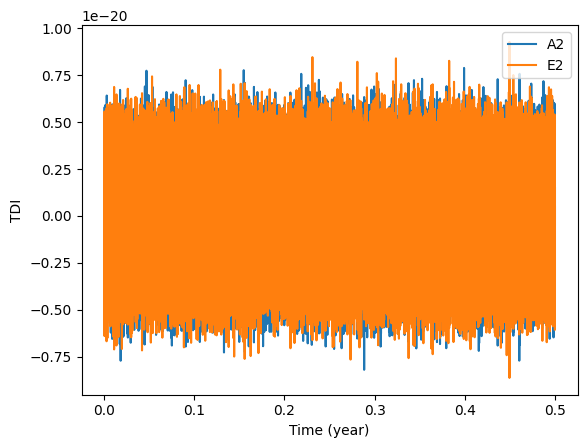

In [6]:
for chan in data_dict["data_channels"]: 
    plt.plot(data_dict["data_time"]/YEAR, data_dict["data_channels"][chan], label=chan)
plt.xlabel("Time (year)")
plt.ylabel("TDI")
plt.legend(loc="upper right")

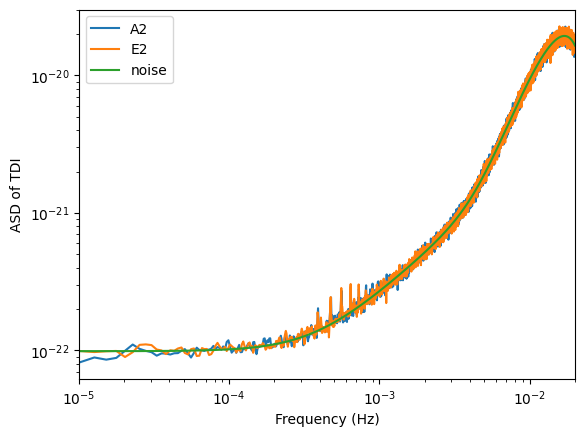

In [7]:
for chan in data_dict["data_channels"]: 
    ff, xf = PSD_window(
        data_array=data_dict["data_channels"][chan], 
        fsample=1./data_generator.dt, 
        window_type="hann", 
        nbin=40, 
    )
    plt.loglog(ff, np.sqrt(xf), label=chan)
plt.loglog(ff, np.sqrt(data_generator.PSDfunc.PSD_A2(ff)), label="noise")
plt.xlim(1e-5, 1./data_generator.dt/2.)

plt.xlabel("Frequency (Hz)")
plt.ylabel("ASD of TDI")
plt.legend(loc="upper left")

## Save data to file 

In [ ]:
# import pickle 

In [ ]:
# data_dict1 = data_generator()
# np.savetxt(
#     fname="./Noisy_Data_SNR_"+format(data_dict1["SNR"], ".2f")+".txt", 
#     X=np.array([data_dict1["data_time"], data_dict1["data_channels"]["A2"], data_dict1["data_channels"]["E2"]]).T, 
#     header="Time (s) | TDI-A2 | TDI-E2", 
# )

# with open("./Noisy_Data_SNR_"+format(data_dict1["SNR"], ".2f")+".pkl", "wb") as outfile: 
#     pickle.dump(data_dict1, outfile)

In [ ]:
# data_dict1 = data_generator(target_SNR=30.)
# np.savetxt(
#     fname="./Noisy_Data_SNR_"+format(data_dict1["SNR"], ".2f")+".txt", 
#     X=np.array([data_dict1["data_time"], data_dict1["data_channels"]["A2"], data_dict1["data_channels"]["E2"]]).T, 
#     header="Time (s) | TDI-A2 | TDI-E2", 
# )

# with open("./Noisy_Data_SNR_"+format(data_dict1["SNR"], ".2f")+".pkl", "wb") as outfile: 
#     pickle.dump(data_dict1, outfile)

## Generate PSD file

In [11]:
# freqs = np.fft.rfftfreq(n=int(0.5*YEAR/25.), d=25.)
# PSDs = np.nan_to_num(data_generator.PSDfunc.PSD_A2(freqs), nan=0.)
# np.savetxt(
#     fname="./TDI_PSDs.txt", 
#     X=np.array([freqs, PSDs]).T, 
#     header="Frequency (Hz) | PSD of A2 or E2 (1/Hz)", 
# )